Import everything needed

In [1]:
import sys
print(sys.executable)

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import json
import shutil
import tempfile
import time
import glob

import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib

from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai import transforms
from monai.transforms import (
    AsDiscrete,
    Activations,
)

from monai.config import print_config
from monai.metrics import DiceMetric
from monai.utils.enums import MetricReduction
from monai.networks.nets import SwinUNETR
from monai import data
from monai.data import decollate_batch
from functools import partial

import torch


print_config()

/home/akaube/PycharmProjects/medseg/venv/bin/python


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
2025-04-24 16:36:48.090798: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-24 16:36:48.114545: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-24 16:36:48.482524: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find Tensor

MONAI version: 1.3.0
Numpy version: 1.26.4
Pytorch version: 2.4.1+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 865972f7a791bf7b42efbcd87c8402bd865b329e
MONAI __file__: /usr/local/lib/python3.10/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.2
scikit-image version: 0.21.0
scipy version: 1.8.0
Pillow version: 9.0.1
Tensorboard version: 2.16.2
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.19.1+cu121
tqdm version: 4.66.4
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 1.3.5
einops version: 0.8.1
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional depen

In [2]:
print("CUDA version:", torch.version.cuda)
print("Is CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")

CUDA version: 12.1
Is CUDA available: True
Device name: NVIDIA GeForce RTX 4090


image shape: (512, 512, 75), mask shape: (512, 512, 75)


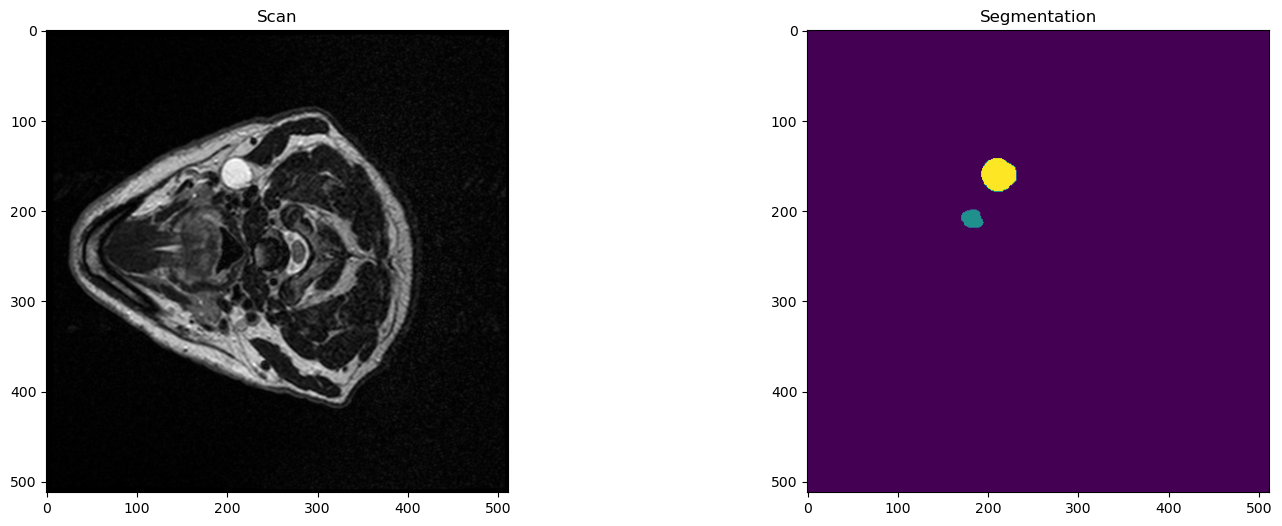

In [3]:
img_path = "/datasets/tdt4265/mic/open/HNTS-MRG/train/10/preRT/10_preRT_T2.nii.gz"
mask_path = "/datasets/tdt4265/mic/open/HNTS-MRG/train/10/preRT/10_preRT_mask.nii.gz"

img = nib.load(img_path).get_fdata()
mask = nib.load(mask_path).get_fdata()

print(f"image shape: {img.shape}, mask shape: {mask.shape}")

plt.figure("image", (18, 6))
plt.subplot(1, 2, 1)

plt.title("Scan")
plt.imshow(img[:, :, 40], cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Segmentation")
plt.imshow(mask[:, :, 40])
plt.show()

Setup data directory

In [4]:
root_dir = tempfile.mkdtemp()
print(root_dir)

/tmp/tmptmv0_m_2


Setup average meter, fold reader, checkpoint saver

In [5]:
class AverageMeter(object):
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = np.where(self.count > 0, self.sum / self.count, self.sum)

In [6]:
# Adjusts file paths using basedir
# Splits dataset into training and validation sets based on fold
def datafold_read(basedir, fold=0):
    tr = []
    val = []

    # Get images and masks
    images = sorted(glob.glob(basedir + "/train/*/preRT/*_preRT_T2.nii.gz"))
    masks = sorted(glob.glob(basedir + "/train/*/preRT/*_preRT_mask.nii.gz"))

    data_dicts = [{"image": img, "mask": msk} for img, msk
                  in zip(images, masks)]

    # Split data into training and validation sets
    # Should it be dict???
    tr = dict(data_dicts[int(len(data_dicts)/2):])
    val = dict(data_dicts[:int(len(data_dicts)/2)])

    tr = data_dicts[int(len(data_dicts)/2):]
    val = data_dicts[:int(len(data_dicts)/2)]

    return tr, val

In [7]:
def save_checkpoint(model, epoch, filename="model.pt",
                    best_acc=0, dir_add=root_dir):
    state_dict = model.state_dict()
    save_dict = {"epoch": epoch, "best_acc": best_acc,
                 "state_dict": state_dict}
    filename = os.path.join(dir_add, filename)
    torch.save(save_dict, filename)
    print("Saving checkpoint", filename)

Setup dataloaders

In [8]:
"""
            transforms.CropForegroundd(
                keys=["image", "mask"],
                source_key="image",
                k_divisible=[roi[0], roi[1], roi[2]],
            ),
            transforms.RandSpatialCropd(
                keys=["image", "mask"],
                roi_size=[roi[0], roi[1], roi[2]],
                random_size=False,
            ),
            """

"""
transforms.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=0),
            transforms.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=1),
            transforms.RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=2),
            transforms.NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
            transforms.RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
            transforms.RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),"""

def relabel_mask(mask):
    mask = mask.clone()
    mask[mask == 2] = 1  # if 2 should map to class 1
    return mask

def get_loader(batch_size, data_dir, fold, roi):
    data_dir = data_dir
    train_files, validation_files = datafold_read(basedir=data_dir, fold=fold)

    # Define transforms
    train_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "mask"]),
    transforms.EnsureChannelFirstd(keys=["image", "mask"]),
        
    # transforms.EnsureTyped(keys=["mask"], dtype=torch.long),  
    transforms.Lambdad(keys=["mask"], func=relabel_mask),
    
    transforms.CropForegroundd(keys=["image", "mask"], source_key="image"),
    transforms.ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(512, 512, 96)),
        
    transforms.RandSpatialCropSamplesd(
        keys=["image", "mask"],
        roi_size=(128, 128, 64),
        num_samples=2,
        random_center=True,
        random_size=False,
    ),
    
    transforms.ToTensord(keys=["image", "mask"]),
])
    
    val_transform = transforms.Compose([
    transforms.LoadImaged(keys=["image", "mask"]),
    transforms.EnsureChannelFirstd(keys=["image"]),
    # transforms.EnsureTyped(keys=["mask"], dtype=torch.long),    # ensure label stays as [B,H,W,D]

    transforms.CropForegroundd(keys=["image", "mask"], source_key="image"),
    transforms.ResizeWithPadOrCropd(keys=["image", "mask"], spatial_size=(512, 512, 96)), # 96 is divisible by 32
        
    transforms.RandSpatialCropSamplesd(
        keys=["image", "mask"],
        roi_size=(128, 128, 64),
        num_samples=2,
        random_center=True,
        random_size=False,
    ),
        
    transforms.ToTensord(keys=["image", "mask"]),
])

    # Make datasets and dataloaders
    # CACHE DATASET?
    train_ds = data.Dataset(data=train_files, transform=train_transform)
    train_loader = data.DataLoader(train_ds,
        batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=False  # num_workers = 8?
    )
    val_ds = data.Dataset(data=validation_files, transform=val_transform)
    val_loader = data.DataLoader(val_ds,
        batch_size=1, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=False
    )

    return train_loader, val_loader

Setup data directory and hyperparameters

In [9]:
data_dir = "/datasets/tdt4265/mic/open/HNTS-MRG"

roi = (64,64,64) # (96,96,96)
batch_size = 1
sw_batch_size = 4
fold = 1
infer_overlap = 0.5
max_epochs = 100
val_every = 10

train_loader, val_loader = get_loader(batch_size, data_dir, fold, roi)

/usr/local/lib/python3.10/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


Create SwinUNETR model

In [10]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using " + "cuda" if torch.cuda.is_available() else "cpu")

model = SwinUNETR(
    img_size=roi,
    in_channels=1,
    out_channels=2,             # Detect two tumors (head and neck)
    feature_size=48,
    drop_rate=0.0,
    attn_drop_rate=0.0,
    dropout_path_rate=0.0,
    use_checkpoint=True,
).to(device)

Using cuda


Define optimizer and loss function

In [11]:
torch.backends.cudnn.benchmark = True

torch.cuda.empty_cache()

from torch.cuda.amp import autocast, GradScaler

loss_function = DiceLoss(to_onehot_y=True, sigmoid=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
dice_metric = DiceMetric(include_background=True, reduction=MetricReduction.MEAN_BATCH, get_not_nans=True)

scaler = GradScaler()
max_epochs = 100

for epoch in range(max_epochs):
    print(f"Epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    for batch_data in train_loader:
        inputs = batch_data["image"].to(device, non_blocking=True)
        labels = batch_data["mask"].to(device, non_blocking=True)
        
        # print(torch.unique(labels)) # should be 0,1

        # Clear out the gradients of all parameters that the optimizer is tracking
        optimizer.zero_grad()

        with torch.amp.autocast("cpu"):
            outputs = model(inputs)
            loss = loss_function(outputs, labels)

        # Backward pass with scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

        print(".", end="")
    # torch.cuda.empty_cache()
    print(f"Avg loss: {epoch_loss / len(train_loader):.4f}")

Epoch 1/100


/tmp/ipykernel_54313/3518534925.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.10/dist-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]


.................................................................Avg loss: 0.5981
Epoch 2/100
.................................................................Avg loss: 0.5651
Epoch 3/100
.................................................................Avg loss: 0.5519
Epoch 4/100
.................................................................Avg loss: 0.5448
Epoch 5/100
.................................................................Avg loss: 0.5367
Epoch 6/100
.................................................................Avg loss: 0.5313
Epoch 7/100
.................................................................Avg loss: 0.5255
Epoch 8/100
.................................................................Avg loss: 0.5214
Epoch 9/100
.................................................................Avg loss: 0.5184
Epoch 10/100
.................................................................Avg loss: 0.5135
Epoch 11/100
..........................................................

KeyboardInterrupt: 

Define train and validation epoch

Define trainer

Now execute training

Wed Apr 16 17:55:49 2025 Epoch: 0


KeyError: Caught KeyError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "C:\Users\zapde\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\_utils\worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "C:\Users\zapde\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "C:\Users\zapde\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\_utils\fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "C:\Users\zapde\monai-install\MONAI\monai\data\dataset.py", line 108, in __getitem__
    return self._transform(index)
  File "C:\Users\zapde\monai-install\MONAI\monai\data\dataset.py", line 93, in _transform
    data_i = self.data[index]
KeyError: 0
